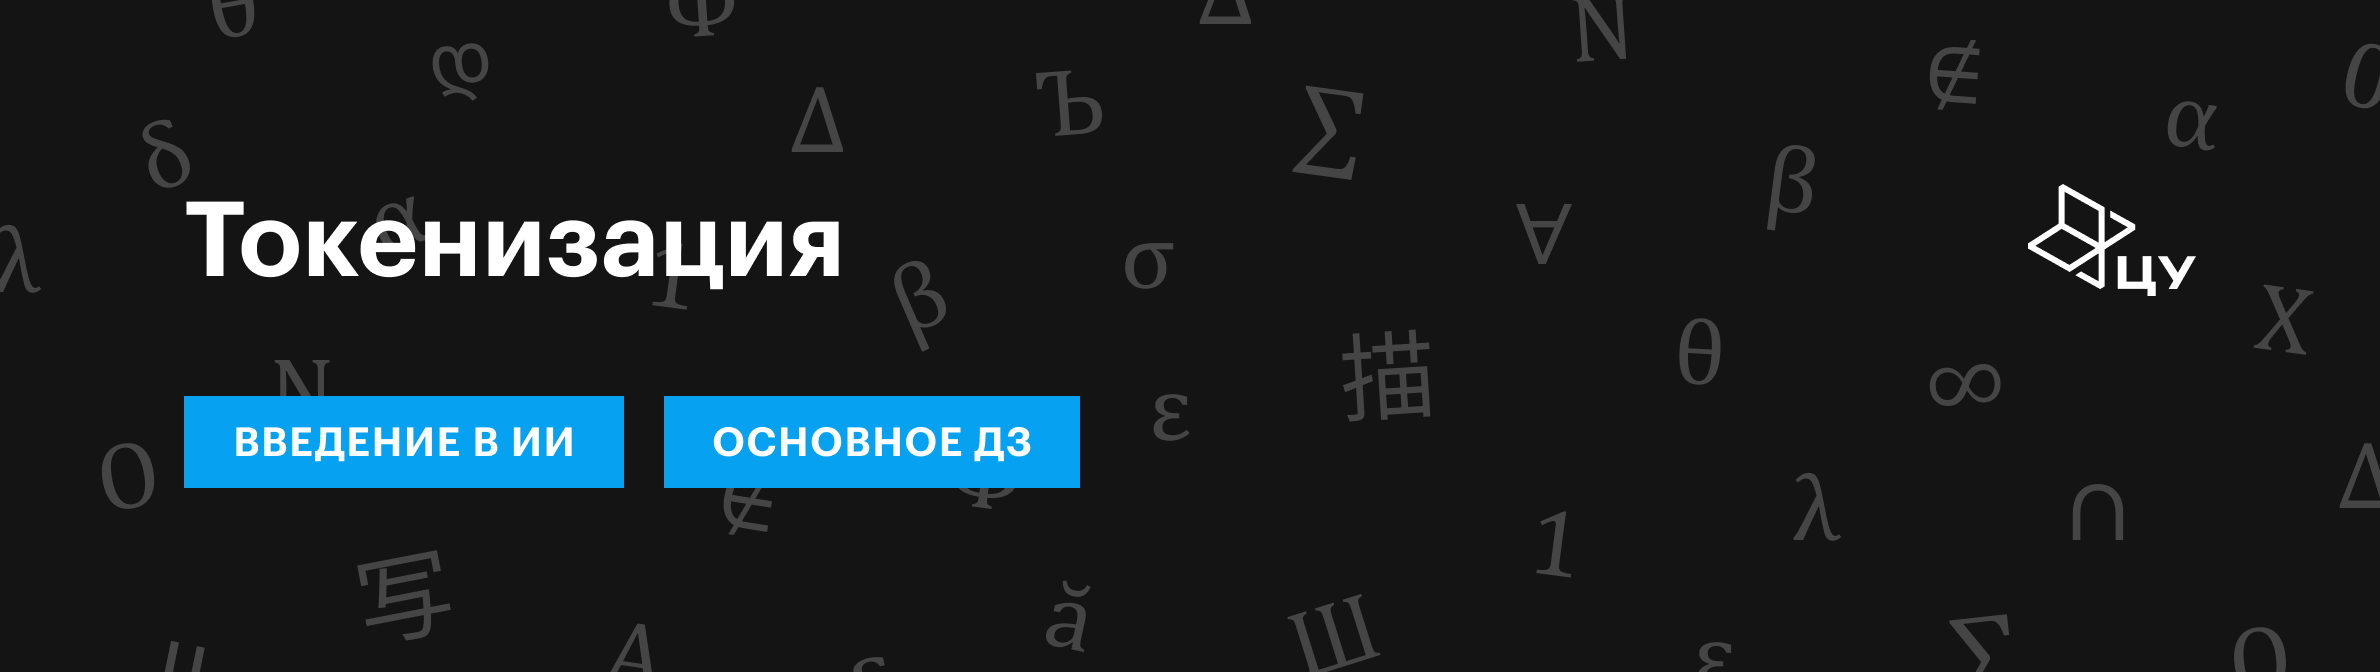

# Основное домашнее задание по теме «Токенизация»

В этом домашнем задании ты разгадаешь зашифрованный текст с помощью n-грамм и правдоподобия.

Текст зашифрован известным алгоритмом: каждая буква единственным образом соотносится с другой буквой. Например, "а" —> "р", "р" —> "п" и так далее. В задании ниже будет пример в виде словаря.

Чтобы разгадать шифр, надо сделать следующее.
1. Найти большую книгу или несколько книг.
2. Посчитать в тексте частотность биграмм и триграмм.
3. Сгенерировать случайный ключ для разгадки шифра.
4. Случайным образом поменять значения в ключе и оценить, улучшает ли это значение логарифма правдоподобия.

Каждый пункт — это отдельное задание, условия которых подробно расписаны ниже.

Правила домашнего задания.
> 1. Нельзя удалять существующие ячейки кода.
>
> 2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
> 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
>6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.





In [4]:
# Тебе пригодятся эти библиотеки
import re # Для фильтрации символов
import random # Для случайностей в коде
import math # Для вычисления логарифма

from collections import Counter # Для подсчёта количества вхождений биграмм и триграмм в тексты

Counter — это обычный словарь, который в качестве значений   принимает только целые числа. Можно не создавать новые ключи вручную, они автоматически добавляются при взаимодействии с Counter. Например, можно сразу писать `counter[key] += 1`.

Подробнее в [документации](https://docs.python.org/3/library/collections.html#collections.Counter).

## Входные данные

В задании две основные входные переменные.
1. Закодированный текст — это последовательность строчных русских букв без знаков препинания и пробелов. Оригинальный текст тоже состоит из русских букв, не имеет знаков препинания и пробелов.
2. Алфавит — русский алфавит строчных букв. Буква «ё» в Python расположена в конце алфавита.

In [5]:
# Закодированный текст
enc_s = 'двдкжижбымодеуавчяпйувшгшмзарыяшодеагжисоячисяжюылкжгдючяпйтцчэжосгржзарскбдьжисочгяшрбштжрацяыуштжосгяшватжцкшукдьжтжбсггшиюдоацшгшиваёсйебжосгбдцшвкшяштагтмэцсосггшияшяатаожипэожбжхкшэцваопяатсошяяпэутабайсуедёкшгшияшкдбысэяжхкшэцгжсгеаужкжяеауотабайгшивацсожвтсоаясйржвяпгшижушбарбсэвпядгтжвяпяшебаьрацюшяпйсрдцгжйсгбсозшгытсгмуайрбакбшцяпэюбаожйсутжотпэжомгмцяпэсцясисомоыкшсэижбцкжйгшикжбжватсюисижэжожирваямагьбжуяжьжзшбмгшитжевшкшэрабаояшбжожиюабаувацшюабауижбмкжводяяацчгежьшгпбмтгаиясзагшизшбатяшгдхсгшедбпйтжвкайтабяжцвдхсггшицгдршцешежлмьжйсочгебаочгцшишцжежйгшизшбыкшщайяшоувшгжиюшэяаггшибдццксйодэгшибдцылршэяагсгшимепвсичомрсвдижбмтсоаводеуавчяпйржоясицсоавскжгдючяпйцтжсияацкшуксьжтжбсв'

In [6]:
# Алфавит
alphabet = ['а', 'б', 'в', 'г', 'д', 'е', 'ж', 'з', 'и', 'й', 'к', 'л', 'м', 'н', 'о', 'п', 'р', 'с', 'т', 'у', 'ф', 'х', 'ц', 'ч', 'ш', 'щ', 'ы', 'ь', 'э', 'ю', 'я', 'ё']

Также дана функция, чтобы сгенерировать случайные ключи для шифра. Эта функция будет использоваться в начале процесса декодирования.

In [7]:
def random_key(alphabet=alphabet):
    perm = alphabet.copy()
    random.shuffle(perm)
    # Ключ: шифробуква -> буква
    return dict(zip(alphabet, perm))

key = random_key()
key # Пример ключа

{'а': 'л',
 'б': 'д',
 'в': 'щ',
 'г': 'н',
 'д': 'я',
 'е': 'ы',
 'ж': 'б',
 'з': 'ю',
 'и': 'ш',
 'й': 'ч',
 'к': 'т',
 'л': 'э',
 'м': 'о',
 'н': 'а',
 'о': 'у',
 'п': 'м',
 'р': 'х',
 'с': 'и',
 'т': 'с',
 'у': 'г',
 'ф': 'к',
 'х': 'ц',
 'ц': 'ь',
 'ч': 'й',
 'ш': 'ф',
 'щ': 'п',
 'ы': 'ж',
 'ь': 'ё',
 'э': 'р',
 'ю': 'в',
 'я': 'е',
 'ё': 'з'}

## Задание 1 [1 балл]

Найди и загрузи большой текст на русском языке. Это может быть одна или несколько книг в формате txt. Например, у автора домашнего задания txt-файл весом 6,1 МБ.

Приложи файл вместе с ноутбуком или загрузи его в код с помощью библиотеки gdown.

Твоё решение

In [ ]:
#!gdown # ссылка

In [8]:
!gdown 1GcQBUc9PLgSuxRje90Iv5-QhyotgCGjM

Downloading...
From: https://drive.google.com/uc?id=1GcQBUc9PLgSuxRje90Iv5-QhyotgCGjM
To: /content/text.txt
100% 1.94M/1.94M [00:00<00:00, 161MB/s]


In [9]:
with open("/content/text.txt", "r") as file:
  large_text = re.sub(r'[^а-яё]', '', file.read().lower()) # Сразу приводим всё к нижнему регистру и оставляем только маленькие буквы на русском языке

## Задание 2 [3 балла]

Обучи биграммные и триграммные «модели». В данном случае «обучение» — это вычисление вероятностей, а модель — обычный словарь.

Для биграммной модели сделай следующее.
1. Посчитай, сколько раз каждая пара соседних токенов входит в датасет.
2. Посчитай, сколько раз каждая буква по отдельности входит в датасет.
3. Вычисли долю случаев (вероятность), когда после буквы «a» следует буква «b», от общего числа появления «a», то есть p(b|a). Для этого совместную встречаемость (сколько раз встретились в датасете в абсолютных единицах) «a» и «b» подели на встречаемость буквы «a» в отдельности.
4. Вероятности сразу логарифмируй, чтобы не вычислять логарифмы при вычислении правдоподобия.

Для триграммной модели сделай следующее.
1. Посчитай, сколько троек соседних токенов входит в датасет.
2. Посчитай, сколько пар входит в датасет (пункт 1 из биграммной модели). Быстрее считать через тройки.
3. Вычисли, сколько раз после пары «ab» следует буква «c». То есть p(c|ab). Для этого совместную встречаемость «ab» и «c» подели на встречаемость пары «ab».
4. Возьми логарифм от вероятности.

In [33]:
def train_bigram_model(text):
    # Посчитай пары токенов
    counts = Counter()
    for a, b in zip(text, text[1:]):
        counts[(a, b)] += 1

    # Частота каждой буквы. Можно передать текст в init Counter
    counts_letter = Counter(text)# Напиши код здесь

    # Логарифм вероятности p(b|a)
    model = {} # Словарь с распределением полученных логарифмов вероятностей
    for (a, b), cnt in counts.items():# Напиши код здесь

        model[(a, b)] = math.log(cnt / counts_letter[a])# Напиши код здесь

    return model

def train_trigram_model(corpus):

    # Посчитай триграммы
    tri = Counter()
    for a, b, c in zip(corpus, corpus[1:], corpus[2:]):# Напиши код здесь
        tri[(a, b, c)] += 1# Напиши код здесь

    # Подсчёт сумм для каждого биграммного контекста (a,b). Считаем, сколько «a» и «b» встречаются рядом. Это можно сделать при помощи словаря с триграммами
    # Пригодится для подсчёта p(c|ab)
    context_sum = Counter()
    for (a, b, c), cnt in tri.items():# Напиши код здесь
        context_sum[(a, b)] += cnt

    # Логарифм вероятности p(c|ab)
    model = {} # Словарь с распределением полученных логарифмов вероятностей
    for (a, b, c), cnt in tri.items():# Напиши код здесь
      model[(a, b, c)] = math.log(cnt / context_sum[(a, b)])# Напиши код здесь

    return model

Проверим работоспособность.

In [34]:
model_bi = train_bigram_model(large_text)
model_tri = train_trigram_model(large_text)

# У автора для данных сочетаний букв получилось -4.01 и -5.80,
# но эти значения могут меняться в зависимости от выбранной книги
model_bi[('а', 'б')], model_tri[('а', 'б', 'в')]

(-4.129027492168525, -5.887029528971099)

## Задание 3 [2 балла]

Напиши функцию для вычисления правдоподобия. Посчитай его как сумму логарифмов вероятностей для биграмм и триграмм в декодированном тексте.

1. Декодируй по текущему ключу шифр. Закодированный текст — строка, после применения ключа тоже должна получиться строка. Ключ — словарь, где одна буква переходит в другую. Пример ключа в начале этого домашнего задания.
2. Иди по тексту и для каждой пары и тройки достань логарифмы вероятностей, вычисли их итоговую сумму. Для каждого набора следующих друг за другом букв вычисли:
$$
LogLikelihood = \sum_{a, b, c} (\log{P(b|a)} + \log{P(c|ab)}).
$$

Для твоего удобства уже реализована функция `log_prob`. Она обращается к словарю просто по ключу. Если значения из декодируемого текста нет в словаре, то функция вернёт очень маленькое значение  — значит, вероятность очень низкая и правдоподобие маленькое.

Такое маловероятно, если для обучения выбран большой текст. В большом тексте, как правило, встречаются все осмысленные пары и тройки букв русского языка.

In [35]:
def log_prob(letters, model, eps=math.log(1e-8)):
    return model.get(letters, eps)

def score_text(ciphertext, key_map, model_bi, model_tri):
    plaintext = ''.join(key_map.get(ch, ch) for ch in ciphertext)# Напиши код здесь # По ключу раскодируй текст
    s = 0.0 # Сюда добавь значения логарифмов вероятности
    for a, b, c in zip(plaintext, plaintext[1:], plaintext[2:]):
        s += log_prob((a, b), model_bi)
        s += log_prob((a, b, c), model_tri)# Напиши код здесь)
    return s

Проверим работоспособность.

In [36]:
score_text(enc_s, key, model_bi, model_tri) # Должно получиться от -16к до -11к в зависимости от изначального случайного словаря

-12345.411066545028

## Задание 4 [1 балл]

Реализуй функцию обновления ключа.

Алгоритм.
1. Выбери случайную пару букв (без повторений).
2. Поменяй местами их значения в ключе.

In [46]:
def swap_two(key_map):
    # Возвращает новый словарь с двумя обменами
    new_key = key_map.copy()
    a, b = random.sample(alphabet, 2)# Напиши код здесь) # Верни две случайные буквы из словаря
    c = new_key.get(a)
    new_key[a] = new_key[b]
    new_key[b] = c
    # Напиши код здесь # Поменяй для них значения местами
    return new_key

Проверим работоспособность.

In [47]:
new_key = swap_two(key)

# Проверка
res1 = sorted((set(key.items()).difference(set(new_key.items()))))
res2 = sorted(set(new_key.items()).difference(set(key.items())))
assert res1[0][0] == res2[0][0] and res1[0][1] == res2[1][1] and res1[1][0] == res2[1][0] and res1[1][1] == res2[0][1], 'Неправильно реализовал'

# Новый ключ
new_key

{'а': 'л',
 'б': 'д',
 'в': 'ц',
 'г': 'н',
 'д': 'я',
 'е': 'ы',
 'ж': 'б',
 'з': 'ю',
 'и': 'ш',
 'й': 'ч',
 'к': 'т',
 'л': 'э',
 'м': 'о',
 'н': 'а',
 'о': 'у',
 'п': 'м',
 'р': 'х',
 'с': 'и',
 'т': 'с',
 'у': 'г',
 'ф': 'к',
 'х': 'щ',
 'ц': 'ь',
 'ч': 'й',
 'ш': 'ф',
 'щ': 'п',
 'ы': 'ж',
 'ь': 'ё',
 'э': 'р',
 'ю': 'в',
 'я': 'е',
 'ё': 'з'}

## Задание 5. Алгоритм для взлома шифра [3 балла]

Собери итоговый алгоритм по шагам.
1. Зафиксируй `seed`, чтобы эксперименты были детерминированными.
2. Обучи биграммные и триграммные модели.
3. Сгенерируй стартовый ключ и посчитай для него логарифм правдоподобия.
4. Далее в цикле:
    * предложи новый ключ;
    * посчитай для него логарифм правдоподобия;
    * если его значение больше наилучшего, обнови ключ и лучшее значение логарифма правдоподобия.

In [62]:
def break_cipher_simple(ciphertext, corpus, alphabet, seed=123, steps=100000, verbose=None):

    # Зафиксируй seed
    random.seed(seed)

    # Инициализируй модели
    model_bi = train_bigram_model(corpus)
    model_tri = train_trigram_model(corpus)

    # Начальный ключ и его значение правдоподобия
    key = random_key(alphabet)
    best_score = score_text(ciphertext, key, model_bi, model_tri)
    best_key = key.copy()

    # Итерируйся n шагов
    for step in range(steps + 1):
        cand = swap_two(key) # Напиши код здесь # Случайная перестановка для ключа
        cand_score = score_text(ciphertext, cand, model_bi, model_tri) # Напиши код здесь # Считаем логарифм правдоподобия для текущего ключа

        # Принимаем, только если правдоподобие стало больше
        if cand_score > best_score : # Напиши код здесь
            key = cand
            best_score = cand_score
            best_key = cand.copy()

        # Печатаем лог каждые n шагов
        if verbose and (step % verbose == 0):
            print(f"step {step}/{steps}  best_score={best_score:.3f}")


    return best_key, best_score

В данном случае используется простейший алгоритм. Он перебирает случайные перестановки и выбирает наилучшую, поэтому вероятность идеального результата мала. Скорее всего потребуется перебирать различные значения `seed`. Это позволит понять общий смысл текста, даже если его не получится декодировать идеально.

Если в ходе работы алгоритма значения логарифма правдоподобия снизилось более чем в два раза, значит, подход верный.

Запустим алгоритм.

In [63]:
best_key, best_score = break_cipher_simple(enc_s, large_text, alphabet, seed=1, verbose=1000)

step 0/8000  score=-12157.423  T=1.00000
step 1000/8000  score=-5069.633  T=0.87500
step 2000/8000  score=-4915.907  T=0.75000
step 3000/8000  score=-4838.196  T=0.62500
step 4000/8000  score=-4808.062  T=0.50000
step 5000/8000  score=-4808.062  T=0.37500
step 6000/8000  score=-4808.062  T=0.25000
step 7000/8000  score=-4808.062  T=0.12500
step 8000/8000  score=-4808.062  T=0.00010


Декодируем шифр по ключу.

In [64]:
''.join([best_key[el] for el in enc_s])

'утукимирьюлупгетянызгтовоюбечьнолупевималняманижьцкивужяныздсяйилавчибечакрухималявночродичесньгодилавнотедискогкухидираввомжулесовомтефазприлаврусотконодевдюйсалаввомнонеделимыйлиришкойстелынедалонныйгдерезагпуфковомнокурьайнишкойсвиавпегикинпеглдерезвомтесалитдаленазчитнывомигоречрайтынувдитнынопрехчесжонызачусвизавралбовьдавюгезчрекросныйжрелизагдилдыйилювюсныйаснамалюлькоаймирскизвомкиритедажмамийилимчтенюевхригнихиборювомдиптокойчерелнорилимжерегтесожерегмирюкитлуннесявпиховырюдвемнабевомборедновушавопурыздиткездернистушаввомсвучоспопицюхизалявпрелявсомосипизвомборькощезнолгтовимжойневвомруссказлуйвомрусьцчойневавомюпытамялючатумирюдалетлупгетянызчилнамсалетакивужянызсдиамнескогкахидират'